In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils import get_spike_activity, sdf, sdf_mean, sdf_maf
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as st
import pandas as pd

In [2]:
#result_path = "/g100_scratch/userexternal/csartor1/results/without_NO/grid_search/"
result_path = "/g100_work/EIRI_E_POLIMI/no_paper/NODS/results/grid_search_new/"
with open("/g100_work/EIRI_E_POLIMI/no_paper/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)

In [3]:
CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])

In [4]:
min = [8,7,6,5,4,3]
plus = [9,8,7,6,5,4]
num_sim = 100

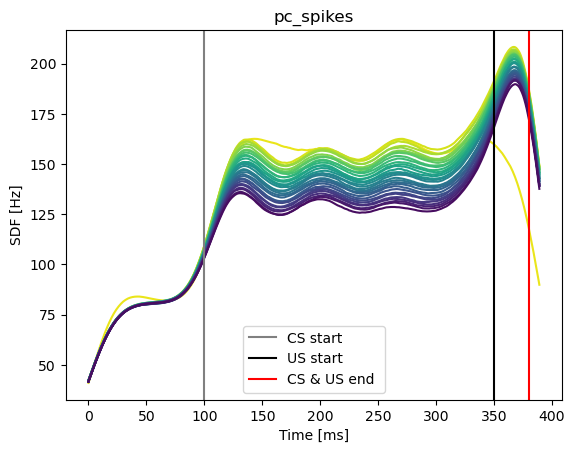

In [13]:
cell = 'pc_spikes'
folder_path = result_path + f"minus8_plus8/"
#folder_path = '/g100_scratch/userexternal/csartor1/results/without_NO/focus/minus7_plus8/m_-50_p_-50/'
sdf_mean_trials_simulations = []
for k in range(0,num_sim):
    file_path = folder_path+ f"sim{k}/"

    df_sdf_mean_over_trials = pd.read_csv(os.path.join(file_path,'sdf_mean_over_trials.csv'))
    sdf_mean_over_trials = df_sdf_mean_over_trials.iloc[:,:].values

    sdf_mean_trials_simulations.append(sdf_mean_over_trials)

stack_sdf_mean = np.stack(sdf_mean_trials_simulations, axis = 0)
t_sim = stack_sdf_mean.shape[2]
sdf_concatenated = np.zeros(t_sim)

median_sdf = np.median(stack_sdf_mean, axis = 0)
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(
cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials)
)

fig = plt.figure()

for trial in range(n_trials):
    plt.plot(median_sdf[trial], palette[trial])
plt.title(cell)
plt.xlabel("Time [ms]")
plt.ylabel("SDF [Hz]")
plt.axvline(CS_start_first, label="CS start", c="grey")
plt.axvline(US_start_first - between_start, label="US start", c="black")
plt.axvline(CS_start_first + CS_burst_dur, label="CS & US end ", c="red")
plt.legend()
plt.show()

In [8]:
cell = 'pc_spikes'

file_path = "/g100_scratch/userexternal/csartor1/results/without_NO/grid_search/minus7_plus8/sim45/"

palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(
cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials)
)
"""sdf_mean_cell = []
sdf_maf_cell = []
step = 5
for trial in range(n_trials):
    start = trial * between_start
    stop = CS_start_first + CS_burst_dur + trial * between_start
    sdf_cell = sdf(start=start, stop=stop, spk=spk, step=step)
    sdf_mean_cell.append(sdf_mean(sdf_cell))
    sdf_maf_cell.append(sdf_maf(sdf_cell))"""

df_sdf_mean_over_trials = pd.read_csv(os.path.join(file_path,'sdf_mean_over_trials.csv'))
sdf_mean_cell = df_sdf_mean_over_trials.iloc[:,:].values


fig = plt.figure()
for trial in range(n_trials):
    plt.plot(sdf_mean_cell[trial], palette[trial])
plt.title(cell)
plt.xlabel("Time [ms]")
plt.ylabel("SDF [Hz]")
plt.axvline(CS_start_first, label="CS start", c="grey")
plt.axvline(US_start_first - between_start, label="US start", c="black")
plt.axvline(CS_start_first + CS_burst_dur, label="CS & US end ", c="red")
plt.legend()
#plt.colorbar(sm, label="Trial")
fig.savefig(os.path.join(result_path,f'aa_sdf_{cell}.png'))

FileNotFoundError: [Errno 2] No such file or directory: '/g100_scratch/userexternal/csartor1/results/without_NO/grid_search/minus7_plus8/sim45/sdf_mean_over_trials.csv'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


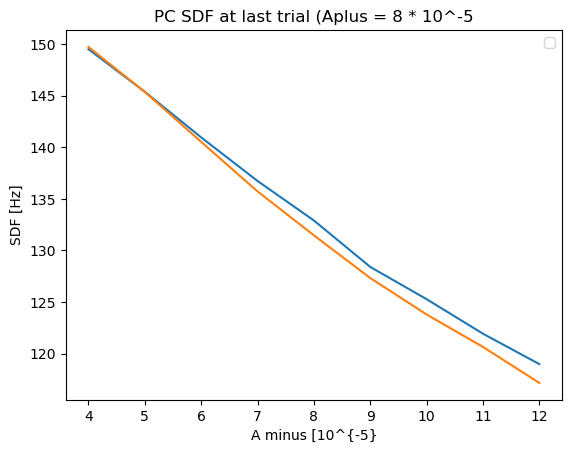

In [11]:
minus = [12,11,10,9,8,7,6,5,4]
#plus = [10,9,8,7,6,5,4,3]
plus = 8
num_sim = 100

cell = 'pc_spikes'

sim_frq_cr = np.zeros((num_sim,len(minus)))
sim_frq_bs = np.zeros((num_sim,len(minus)))

p = plus

for i,m in enumerate(minus):
    
    folder_path = result_path + f"minus{m}_plus{p}/"
    sdf_mean_trials_simulations = []
    
    for k in range (0,num_sim):
        file_path = folder_path+ f"sim{k}/"

        df_sdf_change = pd.read_csv(os.path.join(file_path,'sdf_grif.csv'))
        sdf_baseline = df_sdf_change.iloc[:,0].values
        sdf_cr = df_sdf_change.iloc[:,1].values

        sim_frq_bs[k,i] = sdf_baseline[-1]
        sim_frq_cr[k,i] = sdf_cr[-1]
        
        
sdf_median_bs = np.median(sim_frq_bs, axis = 0)
sdf_median_cr = np.median(sim_frq_cr, axis = 0)

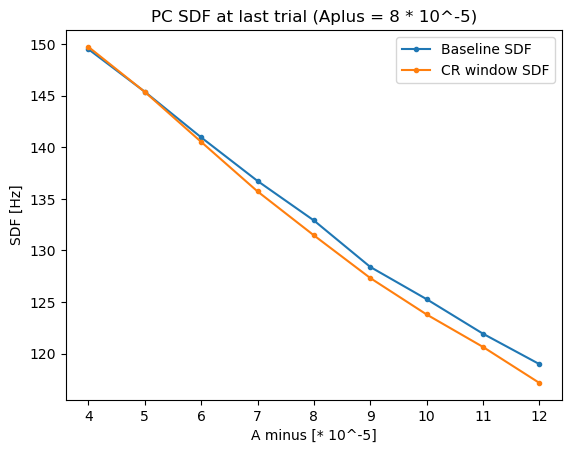

In [16]:
fig = plt.figure()
plt.plot(minus, sdf_median_bs, label = 'Baseline SDF', marker = '.')
plt.plot(minus, sdf_median_cr, label = 'CR window SDF', marker = '.')
plt.title(f'PC SDF at last trial (Aplus = {p} * 10^-5)')
plt.xlabel("A minus [* 10^-5]")
plt.ylabel("SDF [Hz]")
plt.legend()
plt.show()

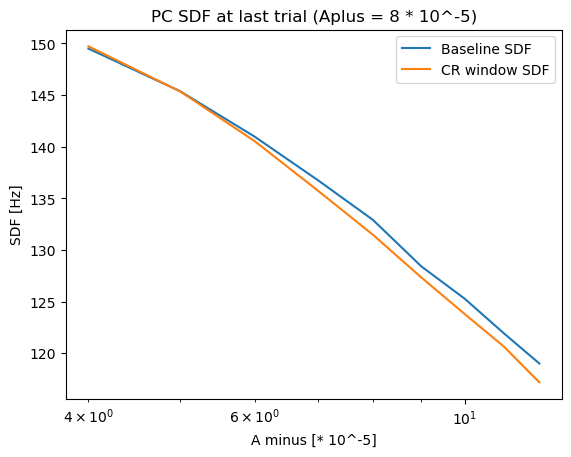

In [12]:
minus = [12,11,10,9,8,7,6,5,4]
plus = [10,9,8,7,6,5,4,3]
plus = 8
num_sim = 100

cell = 'pc_spikes'

sim_frq_cr = np.zeros((num_sim,len(minus)))
sim_frq_bs = np.zeros((num_sim,len(minus)))

p = plus

for i,m in enumerate(minus):
    
    folder_path = result_path + f"minus{m}_plus{p}/"
    sdf_mean_trials_simulations = []
    
    for k in range (0,num_sim):
        file_path = folder_path+ f"sim{k}/"

        df_sdf_change = pd.read_csv(os.path.join(file_path,'sdf_grif.csv'))
        sdf_baseline = df_sdf_change.iloc[:,0].values
        sdf_cr = df_sdf_change.iloc[:,1].values

        sim_frq_bs[k,i] = sdf_baseline[-1]
        sim_frq_cr[k,i] = sdf_cr[-1]
        
        
sdf_median_bs = np.median(sim_frq_bs, axis = 0)
sdf_median_cr = np.median(sim_frq_cr, axis = 0)

In [27]:
minus = [12,11,10,9,8,7,6,5,4]
plus = [10,9,8,7,6,5,4,3]
plus = 8
num_sim = 100
trials_to_eval = 10

cell = 'pc_spikes'

sim_baseline = np.zeros((len(minus),num_sim*trials_to_eval))
sim_cr = np.zeros((len(minus),num_sim*trials_to_eval))


p = plus
bs_change = []
cr_change = []

for i,m in enumerate(minus):
    
    folder_path = result_path + f"minus{m}_plus{p}/"
    sdf_mean_trials_simulations = []
    
    for k in range (0,num_sim):
        file_path = folder_path+ f"sim{k}/"

        df_sdf_change = pd.read_csv(os.path.join(file_path,'sdf_grif.csv'))
        sdf_baseline = df_sdf_change.iloc[:,0].values
        sdf_cr = df_sdf_change.iloc[:,1].values

        sdf_change_baseline = sdf_baseline[1:] - sdf_baseline[1]
        sdf_change_cr = sdf_cr[1:] - sdf_cr[1]
        
        sim_baseline[i,k*10:(k+1)*10] = sdf_change_baseline[-trials_to_eval:]
        sim_cr[i,k*10:(k+1)*10] = sdf_change_cr[-trials_to_eval:]

    bs_change.append(np.median(sim_baseline[i], axis = 0))
    cr_change.append(np.median(sim_cr[i], axis = 0))

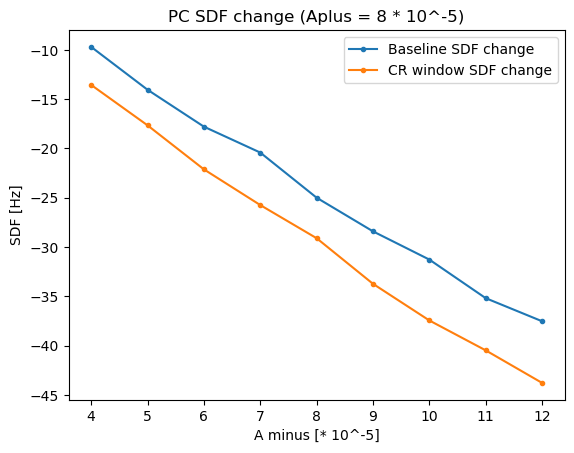

In [28]:
fig = plt.figure()
plt.plot(minus, bs_change, label = 'Baseline SDF change', marker = '.')
plt.plot(minus, cr_change, label = 'CR window SDF change', marker = '.')
plt.title(f'PC SDF change (Aplus = {p} * 10^-5)')
plt.xlabel("A minus [* 10^-5]")
plt.ylabel("SDF [Hz]")
plt.legend()
plt.show()